# Batch/Sequence Benchmark + Test Run

This notebook does three things:
1. Runs all project tests (`pytest -q`).
2. Benchmarks model forward latency over batch sizes `[1, 64, 256, 512]` and sequence lengths `[16, 64, 128, 256]`.
3. Saves a heatmap figure to `figures/bs_seq_benchmark_heatmap.png` and displays it.

Note: A compact benchmark config is used for feasibility across the full matrix.


In [1]:
import os
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import os
import time
import subprocess
from pathlib import Path

import jax
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from flax import nnx

from configs.model_config import ModelConfig
from models.transformer import Transformer
from models.kv_cache import KVCache

ROOT = Path.cwd()
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('JAX devices:', jax.devices())


JAX devices: [CpuDevice(id=0)]


## 1) Run All Tests

In [2]:
test_cmd = ['pytest', '-q']
print('Running:', ' '.join(test_cmd))
result = subprocess.run(test_cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f'pytest failed with code {result.returncode}')


Running: pytest -q


................................ss..                                     [100%]
34 passed, 2 skipped in 17.08s



## 2) Benchmark Grid (Batch x Sequence)

In [3]:
BATCH_SIZES = [1, 64, 256, 512]
SEQ_SIZES = [16, 64, 128, 256]

# Small model for stable matrix benchmarking on one machine.
def make_bench_config(max_seq_len: int) -> ModelConfig:
    return ModelConfig(
        n_layers=2,
        d_model=32,
        n_heads=2,
        n_kv_heads=1,
        vocab_size=512,
        max_seq_len=max_seq_len,
        mlp_hidden=64,
    )


def bench_one(batch_size: int, seq_len: int, repeats: int = 3):
    cfg = make_bench_config(max_seq_len=seq_len)
    model = Transformer(cfg, rngs=nnx.Rngs(params=42))
    cache = KVCache.init(cfg, batch_size=batch_size)
    tokens = jnp.ones((batch_size, seq_len), dtype=jnp.int32)

    # Warmup
    logits, cache2 = model(tokens, cache, pos=0)
    _ = logits.block_until_ready()

    latencies = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        logits, cache2 = model(tokens, cache, pos=0)
        _ = logits.block_until_ready()
        dt = time.perf_counter() - t0
        latencies.append(dt)

    avg_latency = sum(latencies) / len(latencies)
    total_tokens = batch_size * seq_len
    toks_per_sec = total_tokens / max(avg_latency, 1e-9)
    return avg_latency, toks_per_sec

rows = []
for b in BATCH_SIZES:
    for s in SEQ_SIZES:
        lat, tps = bench_one(b, s)
        rows.append({
            'batch_size': b,
            'seq_len': s,
            'latency_s': lat,
            'tokens_per_sec': tps,
            'total_tokens': b * s,
        })
        print(f'b={b:>3}, s={s:>3} -> latency={lat:.4f}s, tokens/s={tps:.2f}')

bench_df = pd.DataFrame(rows)
bench_df


b=  1, s= 16 -> latency=0.0061s, tokens/s=2618.09


b=  1, s= 64 -> latency=0.0063s, tokens/s=10183.02


b=  1, s=128 -> latency=0.0064s, tokens/s=19977.98


b=  1, s=256 -> latency=0.0068s, tokens/s=37500.38


b= 64, s= 16 -> latency=0.0073s, tokens/s=140681.07


...

b=512, s= 16 -> latency=0.0144s, tokens/s=570266.68


b=512, s= 64 -> latency=0.0646s, tokens/s=507505.47


b=512, s=128 -> latency=0.1379s, tokens/s=475143.82


b=512, s=256 -> latency=0.4887s, tokens/s=268198.73


,batch_size,seq_len,latency_s,tokens_per_sec,total_tokens
0,1,16,0.006111,2618.086562,16
1,1,64,0.006285,10183.020149,64
2,1,128,0.006407,19977.976691,128
3,1,256,0.006827,37500.381234,256
4,64,16,0.007279,140681.074869,1024
5,64,64,0.010343,396003.876718,4096
6,64,128,0.019071,429556.475285,8192
7,64,256,0.057600,284442.180447,16384
8,256,16,0.009764,419496.036937,4096
9,256,64,0.036671,446786.605878,16384


## 3) Plot + Save Figure

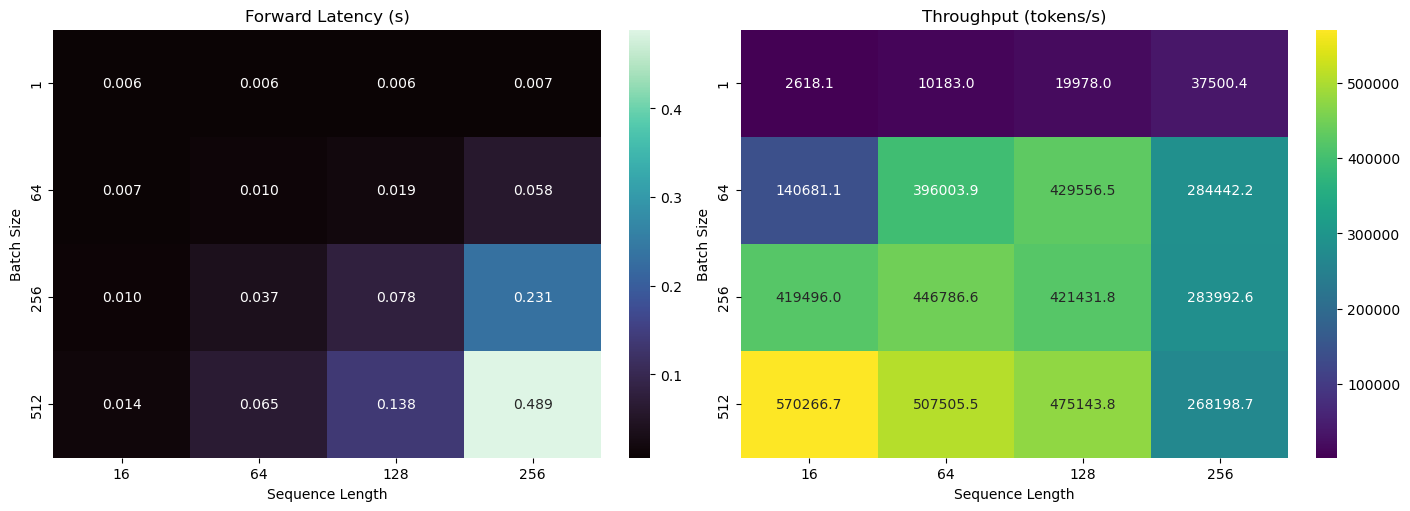

Saved figure: /Users/weilee/Downloads/Jax_demo/figures/bs_seq_benchmark_heatmap.png


In [4]:
lat_pivot = bench_df.pivot(index='batch_size', columns='seq_len', values='latency_s')
tps_pivot = bench_df.pivot(index='batch_size', columns='seq_len', values='tokens_per_sec')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.heatmap(lat_pivot, annot=True, fmt='.3f', cmap='mako', ax=axes[0])
axes[0].set_title('Forward Latency (s)')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Batch Size')

sns.heatmap(tps_pivot, annot=True, fmt='.1f', cmap='viridis', ax=axes[1])
axes[1].set_title('Throughput (tokens/s)')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Batch Size')

out_path = FIG_DIR / 'bs_seq_benchmark_heatmap.png'
fig.savefig(out_path, dpi=160)
plt.show()
print(f'Saved figure: {out_path}')


## 4) Raw Results Table

In [5]:
bench_df.sort_values(['batch_size', 'seq_len']).reset_index(drop=True)


,batch_size,seq_len,latency_s,tokens_per_sec,total_tokens
0,1,16,0.006111,2618.086562,16
1,1,64,0.006285,10183.020149,64
2,1,128,0.006407,19977.976691,128
3,1,256,0.006827,37500.381234,256
4,64,16,0.007279,140681.074869,1024
5,64,64,0.010343,396003.876718,4096
6,64,128,0.019071,429556.475285,8192
7,64,256,0.057600,284442.180447,16384
8,256,16,0.009764,419496.036937,4096
9,256,64,0.036671,446786.605878,16384


## 5) Thorough Speculative-Decoding Experiment

This section stress-tests speculative decoding behavior with multiple prompts, seeds, and speculation lengths (`k`).

It records:
- acceptance rate
- rounds and proposal overhead
- runtime and tokens/sec
- speedup vs naive baseline under the same prompt/seed
- invariant checks (`accepted <= proposed`, `0 <= acceptance <= 1`)


In [6]:
import numpy as np
from engine.generate_naive import generate_naive
from engine.spec_dec import speculative_decode
from configs.model_config import ModelConfig, DraftConfig

prompts = [
    'Hello World',
    'The quick brown fox jumps over the lazy dog',
    'A' * 64,
]
seeds = [0, 1]
k_values = [3, 5, 8]
max_new_tokens = 32

# Keep configs small for a practical full matrix run.
target_cfg = ModelConfig(
    n_layers=3,
    d_model=64,
    n_heads=4,
    n_kv_heads=2,
    vocab_size=256,
    max_seq_len=256,
    mlp_hidden=128,
)

draft_variants = {
    'draft_small_1L': DraftConfig(
        n_layers=1,
        d_model=64,
        n_heads=4,
        n_kv_heads=2,
        vocab_size=256,
        max_seq_len=256,
        mlp_hidden=128,
    ),
    'draft_same_3L': DraftConfig(
        n_layers=3,
        d_model=64,
        n_heads=4,
        n_kv_heads=2,
        vocab_size=256,
        max_seq_len=256,
        mlp_hidden=128,
    ),
}

# Naive baseline per prompt/seed for speedup comparison
naive_baseline = {}
for ptxt in prompts:
    for sd in seeds:
        t0 = time.perf_counter()
        nout = generate_naive(ptxt, max_new_tokens=max_new_tokens, seed=sd, config=target_cfg)
        dt = time.perf_counter() - t0
        naive_baseline[(ptxt, sd)] = {
            'time_s': dt,
            'tokens': len(nout.generated_ids),
            'tps': len(nout.generated_ids) / max(dt, 1e-9),
            'ids': nout.generated_ids,
        }

rows = []
for dname, dcfg in draft_variants.items():
    for ptxt in prompts:
        for sd in seeds:
            for k in k_values:
                t0 = time.perf_counter()
                sout = speculative_decode(
                    ptxt,
                    max_new_tokens=max_new_tokens,
                    k=k,
                    seed=sd,
                    target_config=target_cfg,
                    draft_config=dcfg,
                )
                dt = time.perf_counter() - t0
                gen = len(sout.generated_ids)
                baseline = naive_baseline[(ptxt, sd)]
                rows.append({
                    'draft_variant': dname,
                    'prompt': ptxt,
                    'seed': sd,
                    'k': k,
                    'generated_tokens': gen,
                    'spec_time_s': dt,
                    'spec_tps': gen / max(dt, 1e-9),
                    'acceptance_rate': float(sout.acceptance_rate),
                    'rounds': int(sout.rounds),
                    'proposed_tokens': int(sout.proposed_tokens),
                    'accepted_tokens': int(sout.accepted_tokens),
                    'accepted_le_proposed': bool(sout.accepted_tokens <= sout.proposed_tokens),
                    'acc_in_range': bool(0.0 <= sout.acceptance_rate <= 1.0),
                    'speedup_vs_naive': baseline['time_s'] / max(dt, 1e-9),
                    'matches_naive_ids': bool(sout.generated_ids == baseline['ids']),
                })

spec_df = pd.DataFrame(rows)
print('rows:', len(spec_df))
print('all accepted<=proposed:', spec_df['accepted_le_proposed'].all())
print('all acceptance in [0,1]:', spec_df['acc_in_range'].all())
spec_df.head()


rows: 36
all accepted<=proposed: True
all acceptance in [0,1]: True


,draft_variant,prompt,seed,k,generated_tokens,spec_time_s,spec_tps,acceptance_rate,rounds,proposed_tokens,accepted_tokens,accepted_le_proposed,acc_in_range,speedup_vs_naive,matches_naive_ids
0,draft_small_1L,Hello World,0,3,32,3.297787,9.703477,0.605263,13,38,23,True,True,0.805099,False
1,draft_small_1L,Hello World,0,5,32,0.865546,36.970894,0.531915,10,47,25,True,True,3.067479,False
2,draft_small_1L,Hello World,0,8,32,0.950548,33.664778,0.262500,11,80,21,True,True,2.793171,False
3,draft_small_1L,Hello World,1,3,32,0.824616,38.805918,0.702703,13,37,26,True,True,0.380299,False
4,draft_small_1L,Hello World,1,5,32,0.847616,37.752960,0.489796,10,49,24,True,True,0.369980,False


In [7]:
summary = (
    spec_df.groupby(['draft_variant', 'k'], as_index=False)
    .agg(
        acceptance_rate_mean=('acceptance_rate', 'mean'),
        speedup_vs_naive_mean=('speedup_vs_naive', 'mean'),
        spec_tps_mean=('spec_tps', 'mean'),
        rounds_mean=('rounds', 'mean'),
        proposed_tokens_mean=('proposed_tokens', 'mean'),
        match_naive_rate=('matches_naive_ids', 'mean'),
    )
)
summary


,draft_variant,k,acceptance_rate_mean,speedup_vs_naive_mean,spec_tps_mean,rounds_mean,proposed_tokens_mean,match_naive_rate
0,draft_same_3L,3,0.388720,0.890500,24.439002,15.500000,45.166667,0.0
1,draft_same_3L,5,0.254410,0.820512,22.345020,14.833333,69.500000,0.0
2,draft_same_3L,8,0.167689,0.649096,17.835682,14.833333,105.500000,0.0
3,draft_small_1L,3,0.543439,0.756037,28.862633,14.166667,40.833333,0.0
4,draft_small_1L,5,0.378794,1.199951,32.003052,12.333333,57.666667,0.0
5,draft_small_1L,8,0.229406,1.178371,31.378051,12.666667,89.333333,0.0


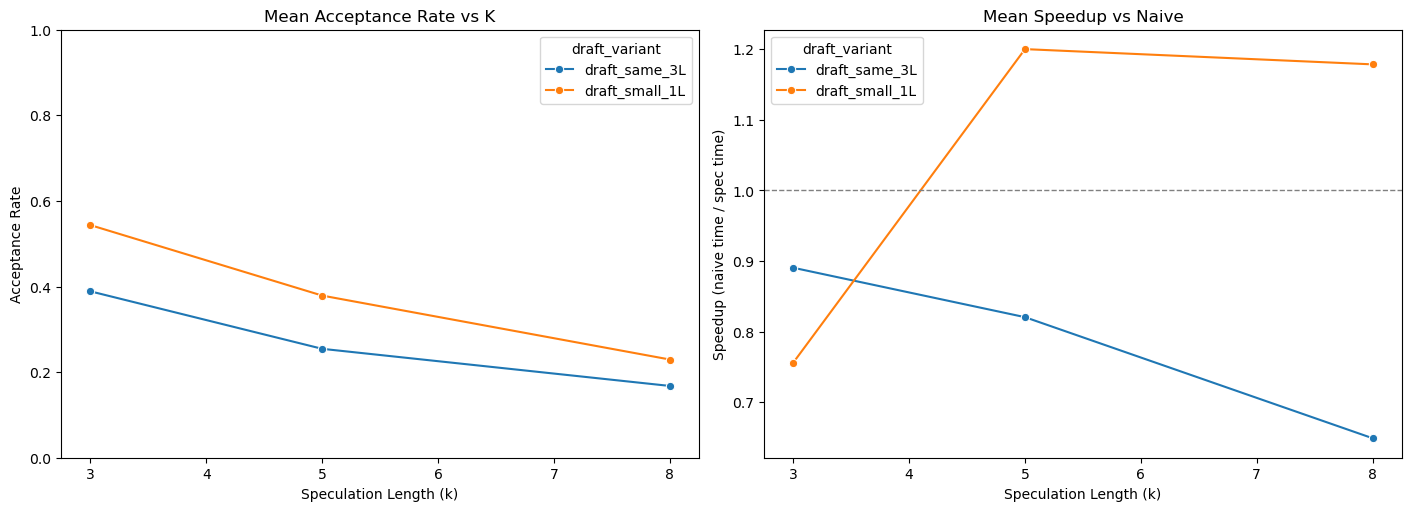

Saved figure: /Users/weilee/Downloads/Jax_demo/figures/spec_dec_thorough_summary.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.lineplot(data=summary, x='k', y='acceptance_rate_mean', hue='draft_variant', marker='o', ax=axes[0])
axes[0].set_title('Mean Acceptance Rate vs K')
axes[0].set_xlabel('Speculation Length (k)')
axes[0].set_ylabel('Acceptance Rate')
axes[0].set_ylim(0, 1)

sns.lineplot(data=summary, x='k', y='speedup_vs_naive_mean', hue='draft_variant', marker='o', ax=axes[1])
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Mean Speedup vs Naive')
axes[1].set_xlabel('Speculation Length (k)')
axes[1].set_ylabel('Speedup (naive time / spec time)')

out_path = FIG_DIR / 'spec_dec_thorough_summary.png'
fig.savefig(out_path, dpi=160)
plt.show()
print('Saved figure:', out_path)


In [9]:
csv_path = FIG_DIR / 'spec_dec_thorough_results.csv'
spec_df.to_csv(csv_path, index=False)
print('Saved table:', csv_path)
spec_df.sort_values(['draft_variant', 'k', 'seed']).head(20)


Saved table: /Users/weilee/Downloads/Jax_demo/figures/spec_dec_thorough_results.csv


,draft_variant,prompt,seed,k,generated_tokens,spec_time_s,spec_tps,acceptance_rate,rounds,proposed_tokens,accepted_tokens,accepted_le_proposed,acc_in_range,speedup_vs_naive,matches_naive_ids
18,draft_same_3L,Hello World,0,3,32,1.328609,24.085340,0.409091,15,44,18,True,True,1.998364,False
24,draft_same_3L,The quick brown fox jumps over the lazy dog,0,3,32,1.278260,25.034030,0.386364,15,44,17,True,True,1.388156,False
30,draft_same_3L,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,0,3,32,1.428970,22.393757,0.386364,15,44,17,True,True,1.258309,False
21,draft_same_3L,Hello World,1,3,32,1.251320,25.573003,0.441860,15,43,19,True,True,0.250616,False
27,draft_same_3L,The quick brown fox jumps over the lazy dog,1,3,32,1.274633,25.105263,0.361702,16,47,17,True,True,0.219823,False
33,draft_same_3L,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1,3,32,1.309189,24.442618,0.346939,17,49,17,True,True,0.227730,False
19,draft_same_3L,Hello World,0,5,32,1.458226,21.944477,0.239437,15,71,17,True,True,1.820736,False
25,draft_same_3L,The quick brown fox jumps over the lazy dog,0,5,32,1.471561,21.745610,0.239437,15,71,17,True,True,1.205811,False
31,draft_same_3L,AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,0,5,32,1.421316,22.514348,0.239437,15,71,17,True,True,1.265085,False
22,draft_same_3L,Hello World,1,5,32,1.335136,23.967592,0.338983,13,59,20,True,True,0.234883,False


## 6) Best Usage Figure #1: Batch Size x Sequence Length

This figure highlights where throughput is highest in the batch/sequence grid.


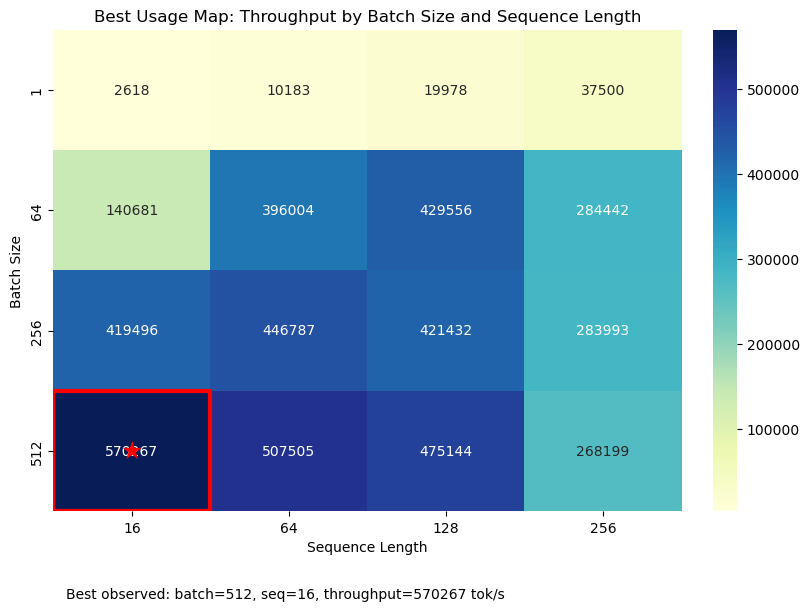

Saved figure: /Users/weilee/Downloads/Jax_demo/figures/bs_seq_best_usage.png


In [10]:
import numpy as np

best_row = bench_df.loc[bench_df['tokens_per_sec'].idxmax()]

pivot_tps = bench_df.pivot(index='batch_size', columns='seq_len', values='tokens_per_sec')

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
sns.heatmap(pivot_tps, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Best Usage Map: Throughput by Batch Size and Sequence Length')
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Batch Size')

# Mark best cell with a red box + star
bs_list = list(pivot_tps.index)
sl_list = list(pivot_tps.columns)
bi = bs_list.index(best_row['batch_size'])
si = sl_list.index(best_row['seq_len'])

rect = plt.Rectangle((si, bi), 1, 1, fill=False, edgecolor='red', linewidth=3)
ax.add_patch(rect)
ax.text(si + 0.5, bi + 0.5, '★', color='red', ha='center', va='center', fontsize=18, fontweight='bold')

ax.text(
    0.02,
    -0.18,
    f"Best observed: batch={int(best_row['batch_size'])}, seq={int(best_row['seq_len'])}, "
    f"throughput={best_row['tokens_per_sec']:.0f} tok/s",
    transform=ax.transAxes,
    fontsize=10,
)

out_path = FIG_DIR / 'bs_seq_best_usage.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
plt.show()
print('Saved figure:', out_path)


## 7) Best Usage Figure #2: Speculative `k` vs Speedup

This figure shows which speculation length `k` gives the highest speedup vs naive.


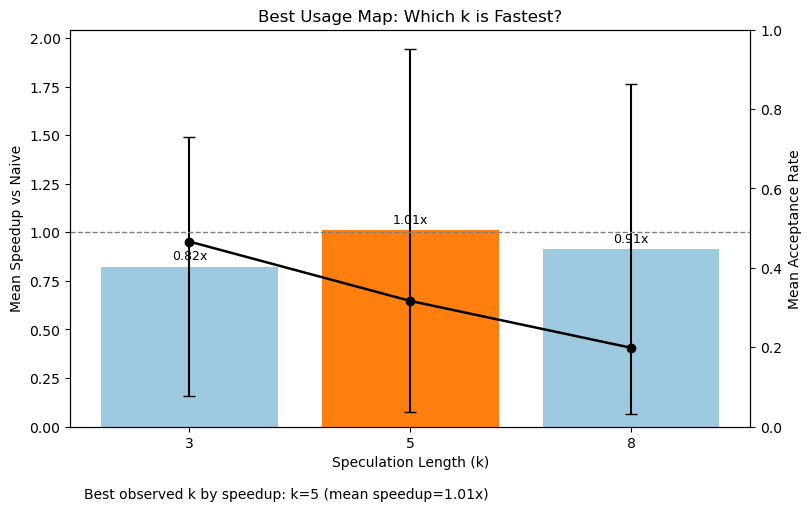

Saved figure: /Users/weilee/Downloads/Jax_demo/figures/spec_k_best_usage.png


,k,mean_speedup,std_speedup,mean_acceptance
0,3,0.823268,0.666399,0.466079
1,5,1.010232,0.935067,0.316602
2,8,0.913734,0.851096,0.198548


In [11]:
k_summary = (
    spec_df.groupby('k', as_index=False)
    .agg(
        mean_speedup=('speedup_vs_naive', 'mean'),
        std_speedup=('speedup_vs_naive', 'std'),
        mean_acceptance=('acceptance_rate', 'mean'),
    )
    .sort_values('k')
)

best_k_row = k_summary.loc[k_summary['mean_speedup'].idxmax()]
best_k = int(best_k_row['k'])

fig, ax1 = plt.subplots(figsize=(8, 5), constrained_layout=True)

bars = ax1.bar(
    k_summary['k'].astype(str),
    k_summary['mean_speedup'],
    yerr=k_summary['std_speedup'].fillna(0.0),
    capsize=4,
    color=['#9ecae1' if int(k) != best_k else '#ff7f0e' for k in k_summary['k']],
)
ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('Mean Speedup vs Naive')
ax1.set_xlabel('Speculation Length (k)')
ax1.set_title('Best Usage Map: Which k is Fastest?')

# label bars
for b, v in zip(bars, k_summary['mean_speedup']):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f'{v:.2f}x', ha='center', va='bottom', fontsize=9)

# acceptance as secondary line
ax2 = ax1.twinx()
ax2.plot(k_summary['k'].astype(str), k_summary['mean_acceptance'], marker='o', color='black', linewidth=1.8)
ax2.set_ylabel('Mean Acceptance Rate')
ax2.set_ylim(0, 1)

ax1.text(
    0.02,
    -0.18,
    f"Best observed k by speedup: k={best_k} (mean speedup={best_k_row['mean_speedup']:.2f}x)",
    transform=ax1.transAxes,
    fontsize=10,
)

out_path = FIG_DIR / 'spec_k_best_usage.png'
fig.savefig(out_path, dpi=170, bbox_inches='tight')
plt.show()
print('Saved figure:', out_path)

k_summary
